## Линейная регрессия

В этом практическом задании четыре обязательных и одна дополнительная задача. 
<br>
*Обязательные задачи* помогут проверить, что вы действительно усвоили материал. Если у вас всё получилось, можете переходить к следующей теме.
<br>
*Дополнительная задача* для тех, кто хочет потренироваться в подготовке данных для обучения модели и использовании алгоритма линейной регрессии. 
<br>
Удачи!

Цели практического задания: 

1.   Научиться пользоваться моделью линейной регрессии.
2.   Потренироваться в использовании метрики MAE.
3.   Научиться использовать категориальные фичи для задачи линейной регрессии.




В этом практическом задании вы будете работать с данными, которые мы разбирали в видео. В них указаны расходы, выставленные медицинскими страховыми компаниями по клиентам.

Этот датасет мы будем использовать для предсказания расходов по страховке, исходя из характеристик клиента.

**Описание данных:**

*age*: возраст;

*sex*: пол женский/мужской;

*bmi*: индекс массы тела;

*children*: количество детей/иждивенцев, входящих в страховку;

*smoker*: курящий/некурящий;

*region*: район проживания в США, северо-восток, юго-восток, юго-запад, северо-запад;

*charges*: расходы по страховке.

## Обязательные задачи

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split 

In [4]:
df = pd.read_csv('data/insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


**Задача 0. Подготовка данных для обучения**

Проделайте следующие шаги на этом датафрейме:

1. Создайте датафрейм, положите в него данные по клиентам-женщинам, у которых нет детей, и сумма страховки менее 15 тысяч долларов.
2. Постройте график зависимости стоимости страховки от возраста. Проверьте, что у вас получился следующий график.

In [16]:
# Ваш код здесь
df_new = df[(df['children']==0) & (df['charges']<15000)]
df_new.head()

,age,sex,bmi,children,smoker,region,charges
4,32,male,28.88,0,no,northwest,3866.8552
5,31,female,25.74,0,no,southeast,3756.6216
10,25,male,26.22,0,no,northeast,2721.3208
12,23,male,34.40,0,no,southwest,1826.8430
13,56,female,39.82,0,no,southeast,11090.7178


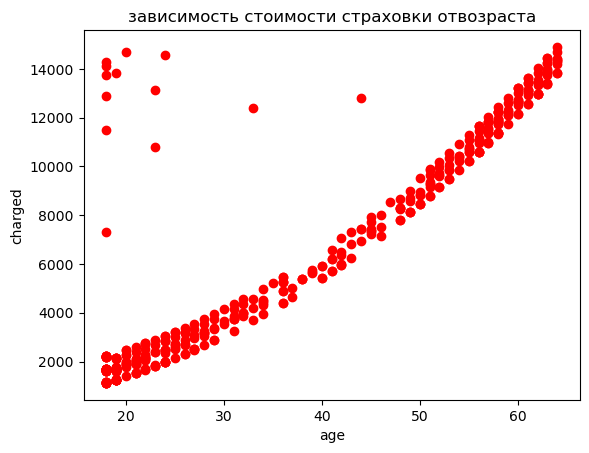

In [22]:
show_age_charges(df_new)

**Задача 1. Удаление выбросов и обучение модели линейной регрессии**

Проделайте следующие шаги:

3. Удалите  значения charges в выбросах, их на картинке 10 штук. Заново отрисуйте график и убедитесь, что выбросы действительно удалены.
4. Поделите данные на треин и тест выборку в отношении 80/20.
5. Обучите модель линейной регрессии с дефолтными параметрами на одной входной фиче: age; померьте качество на тесте с помощью метрики MAE.

In [30]:
# Ваш код здесь
outliers1 = df_new[(df_new.charges > 6000) & (df_new.age < 30)].index
outliers2 = df_new[(df_new.charges > 12000) & (df_new.age < 50)].index

df_clean = df_new.drop(list(outliers1) + list(outliers2))
print(df_new.shape)
print(df_clean.shape)

(436, 7)
(423, 7)


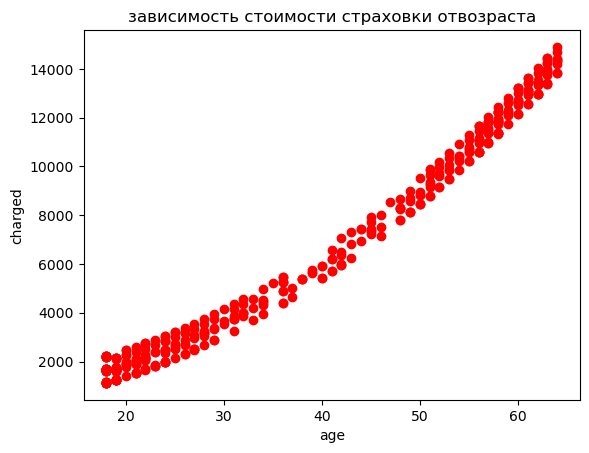

In [32]:
show_age_charges(df_clean)

In [72]:
train, test = train_test_split(df_clean, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(train[['age']], train['charges'])

LinearRegression()

In [76]:
pred = lr.predict(test[['age']])
mean_absolute_error(test.charges, pred)

558.5354802181131

**Задача 2. Обучение модели линейной регрессии на нескольких фичах**

Обучите модель линейной регрессии с дефолтными параметрами на данных из предыдущего задания на всех непрерывных фичах, которые есть в датасете. Заранее удалите фичи, в которых присутствует только одно единственное значение.

Рассчитайте новое значение метрики на тестовой выборке. Улучшилась ли метрика по сравнению с предыдущим заданием?

In [112]:
# Ваш код здесь
df_clean

single_value_cols = df_clean.columns[df_clean.nunique() == 1].tolist()
print("Столбцы с одним значением:", single_value_cols)

df_updated = df_clean.drop(columns = single_value_cols)

continuous_cols = df_updated.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Непрерывные фичи:", continuous_cols)


Столбцы с одним значением: ['children', 'smoker']
Непрерывные фичи: ['age', 'bmi', 'charges']


In [116]:
df_updated = df_updated[continuous_cols]
df_updated

,age,bmi,charges
4,32,28.880,3866.85520
5,31,25.740,3756.62160
10,25,26.220,2721.32080
12,23,34.400,1826.84300
13,56,39.820,11090.71780
...,...,...,...
1325,61,33.535,13143.33665
1326,42,32.870,7050.02130
1334,18,31.920,2205.98080
1335,18,36.850,1629.83350


In [128]:
train, test = train_test_split(df_updated, test_size=0.2, random_state=42)

lr2 = LinearRegression()
lr2.fit(train[['age', 'bmi']], train.charges)

LinearRegression()

In [130]:
pred2 = lr2.predict(test[['age', 'bmi']])
mean_absolute_error(test.charges, pred2)

560.4489033932904

**Задача 3. Обучение модели линейной регрессии с категориальными фичами**

Обучите модель линейной регрессии с дефолтными параметрами на всех фичах, которые есть в датасете. Заранее удалите фичи, в которых присутствует только одно единственное значение. Категориальные фичи преобразуйте с помощью OneHotEncoder.

Рассчитайте новое значение метрики на тестовой выборке. Улучшилась ли метрика по сравнению с предыдущим заданием?

In [ ]:
# Ваш код здесь

## Дополнительные задачи

Попробуйте обучить модель линейной регрессии на всех данных, которые лежат в `insurance.csv`. Чтобы улучшить показание метрики, попробуйте проделать следующие действия:
- проанализируйте данные на выбросы, подумайте над стратегией как с ними работать так, чтобы модель не ухудшала из-за них свою предсказательную способность;
- используйте только значимые фичи, то есть те, которые влияют на целевую переменную (в этом случае может помочь матрица корреляций и построение графиков зависимости категориальных фичей от целевой переменной);
- используйте scaler для преобразования входных данных;
- попробуйте сгенерировать новые фичи (например из `age` сделать различные категории: молодой, старый).


-

-

-

-

-

-

-

-

In [ ]:
# Решение (Задача 1)
def show_age_charges(df):
    plt.plot(df['age'], df['charges'], 'ro') 
    plt.xlabel('age')
    plt.ylabel('charges')
    plt.title('Зависимость стоимости страховки от возраста')
    plt.show()

(228, 7)


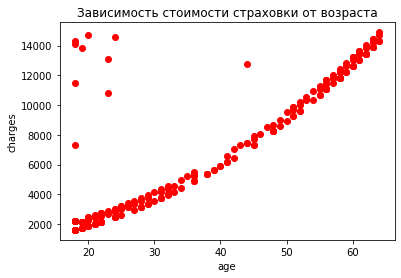

In [ ]:
df_new = df[(df.children==0) & (df.charges < 15000) & (df.sex == 'female')]
print(df_new.shape)

show_age_charges(df_new)

(218, 7)


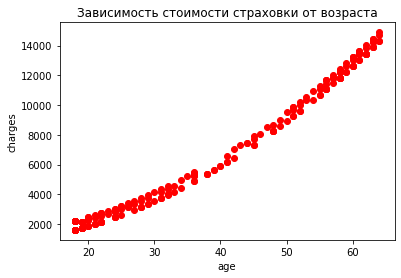

In [ ]:
# один из возможных вариантов удаления
indx = df_new[(df_new.charges >= 6000) & (df_new.age<30)].index
indx1 = df_new[(df_new.charges >= 12000) & (df_new.age<50)].index

df_new = df_new.drop(list(indx) + list(indx1))
print(df_new.shape)

show_age_charges(df_new)

In [ ]:
train, test = train_test_split(df_new, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(train[['age']], train.charges)
pred = lr.predict(test[['age']])
mean_absolute_error(test.charges, pred)

589.2828328455392

Замечание:
В видео мы обучали линейную регрессию на данных с выбросами, и ошибка была порядка ~1500$. Сейчас мы обучили модель без выбросов, и модель показала результат намного лучше. Линейная регрессия очень чувствительна к наличию выбросов в обучающей выборке. Поэтому данные нужно хорошо подготовить, прежде чем обучать на них линейную регрессию. 

-

-

-

In [ ]:
# Решение (Задача 2)
new_cols = ['age', 'bmi', 'charges']
train, test = train_test_split(df_new[new_cols], test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(train.drop(['charges'], axis=1), train.charges)
pred = lr.predict(test.drop(['charges'], axis=1))
mean_absolute_error(test.charges, pred)

590.8305083474556

-

-

-

In [ ]:
# Решение (Задача 3)
# смотрим какие колонки удалить
df_new.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,218.000000,218,218.000000,218.0,218,218,218.000000
unique,NaN,1,NaN,NaN,1,4,NaN
top,NaN,female,NaN,NaN,no,northeast,NaN
freq,NaN,218,NaN,NaN,218,58,NaN
mean,38.775229,NaN,30.310986,0.0,NaN,NaN,6739.594019
std,16.416243,NaN,5.958165,0.0,NaN,NaN,4455.839013
min,18.000000,NaN,17.290000,0.0,NaN,NaN,1607.510100
25%,22.000000,NaN,26.053750,0.0,NaN,NaN,2475.245350
50%,36.000000,NaN,29.925000,0.0,NaN,NaN,5269.996975
75%,56.000000,NaN,34.727500,0.0,NaN,NaN,11412.150800


In [ ]:
df_new2 = df_new.drop(['sex', 'children', 'smoker'], axis=1)

train, test = train_test_split(df_new2, test_size=0.2, random_state=42)
train.head()

,age,bmi,region,charges
521,32,44.220,southeast,3994.17780
579,25,23.465,northeast,3206.49135
671,29,31.160,northeast,3943.59540
789,62,29.920,southeast,13457.96080
523,38,37.730,southeast,5397.61670


In [ ]:
from sklearn.preprocessing import OneHotEncoder

# кодируем с помощью ohe фичу region
ohe = OneHotEncoder(handle_unknown='ignore')
train_enc = pd.DataFrame(ohe.fit_transform(train[['region']]).toarray(), columns = ohe.categories_)
test_enc = pd.DataFrame(ohe.transform(test[['region']]).toarray(), columns = ohe.categories_)

train_enc.head()

,northeast,northwest,southeast,southwest
0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0
3,0.0,0.0,1.0,0.0
4,0.0,0.0,1.0,0.0


In [ ]:
# добавляем преобразованную категориальную фичу в датафрейм. исходное представление фичи дропаем
train = train.join(train_enc.set_index(train.index)).drop(['region'], axis=1)
test = test.join(test_enc.set_index(test.index)).drop(['region'], axis=1)
train.head()

,age,bmi,charges,"(northeast,)","(northwest,)","(southeast,)","(southwest,)"
521,32,44.220,3994.17780,0.0,0.0,1.0,0.0
579,25,23.465,3206.49135,1.0,0.0,0.0,0.0
671,29,31.160,3943.59540,1.0,0.0,0.0,0.0
789,62,29.920,13457.96080,0.0,0.0,1.0,0.0
523,38,37.730,5397.61670,0.0,0.0,1.0,0.0


In [ ]:
lr.fit(train.drop(['charges'], axis=1), train.charges)
pred = lr.predict(test.drop(['charges'], axis=1))
mean_absolute_error(test.charges, pred)

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['str', 'tuple']. An error will be raised in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:1692: FutureWarning: Feature names only support names that are all strings. Got feature names with dtypes: ['str', 'tuple']. An error will be raised in 1.2.
  FutureWarning,


535.5915097964667